# Regresión lineal para predecir O₃ con NO, NO₂, NOX y CO
**Datos:** SIMAT - contaminantes horarios 2026 (`contaminantes_2026.csv`, enero-febrero 2026) - https://aire.cdmx.gob.mx/descargas/Opendata/anuales_horarios/contaminantes_2026.csv  


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

ESTACION = "MER"   # Merced
VARS_X = ["NO", "NO2", "NOX", "CO"]

## 1. Carga del CSV

In [ ]:
RUTA = "/content/contaminantes_2026.csv"

with open(RUTA, encoding="utf-8") as f:
    lineas = [next(f, "") for _ in range(30)]
fila_header = next(i for i, l in enumerate(lineas) if l.lower().startswith('"date"'))
print("Metadatos del archivo:")
print("".join(lineas[:fila_header]))

raw = pd.read_csv(RUTA, skiprows=fila_header, encoding="utf-8")
print(raw.shape)
raw.head()

Metadatos del archivo:
city: Ciudad de México
cityCode: MEX
country: México
mesurementAgency: SIMAT
URL: http://www.aire.cdmx.gob.mx
timeStamp: 2026/01/01 al 2026/02/28
average_interval: 001h
version: SAM_26_DGS
SAM-AE-RAMA-2026-20260413-1

(433296, 5)


,date,id_station,id_parameter,valor,unit
0,2026-01-01 00:00:00,ACO,CO,NaN,NaN
1,2026-01-01 00:00:00,ACO,NO,NaN,NaN
2,2026-01-01 00:00:00,ACO,NO2,NaN,NaN
3,2026-01-01 00:00:00,ACO,NOX,NaN,NaN
4,2026-01-01 00:00:00,ACO,O3,NaN,NaN


## 2. Limpieza y formato ancho (una columna por contaminante)

In [ ]:
raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
raw["valor"] = pd.to_numeric(raw["valor"], errors="coerce")   # celdas vacías -> NaN
raw = raw.dropna(subset=["date"])

print("Periodo:", raw["date"].min(), "->", raw["date"].max())
print("Estaciones disponibles:", sorted(raw["id_station"].unique()))

est = raw[(raw["id_station"] == ESTACION) & (raw["id_parameter"].isin(["O3"] + VARS_X))].copy()
est.loc[est["valor"] < 0, "valor"] = np.nan   # valores negativos = lecturas inválidas

# Una fila por hora, una columna por contaminante
df = est.pivot_table(index="date", columns="id_parameter", values="valor", aggfunc="mean")
print("Faltantes por variable (%):")
print((df.isna().mean() * 100).round(2))

df = df[["O3"] + VARS_X].dropna()
print(f"\nEstación {ESTACION}: {len(df)} horas completas para el modelo")
df.describe().round(2)

Periodo: 2026-01-01 00:00:00 -> 2026-02-28 23:00:00
Estaciones disponibles: ['ACO', 'AJM', 'AJU', 'ATI', 'BJU', 'CAM', 'CCA', 'CHO', 'CUA', 'CUT', 'FAC', 'FAR', 'GAM', 'HGM', 'INN', 'IZT', 'LLA', 'LPR', 'MER', 'MGH', 'MON', 'MPA', 'NEZ', 'PED', 'SAC', 'SAG', 'SFE', 'TAH', 'TLA', 'TLI', 'UAX', 'UIZ', 'VIF', 'XAL']
Faltantes por variable (%):
id_parameter
CO     0.30
NO     0.52
NO2    0.97
NOX    0.52
O3     4.09
dtype: float64

Estación MER: 1283 horas completas para el modelo


id_parameter,O3,NO,NO2,NOX,CO
count,1283.00,1283.00,1283.00,1283.00,1283.00
mean,31.58,36.22,39.79,76.03,1.12
std,31.79,51.79,17.72,62.14,0.56
min,3.00,0.00,7.00,7.00,0.27
25%,6.00,4.00,27.00,32.00,0.71
50%,18.00,11.00,37.00,53.00,0.95
75%,51.00,48.00,50.00,100.50,1.42
max,143.00,365.00,105.00,451.00,3.72


## a) Regresión lineal: O₃ ~ NO + NO₂ + NOX + CO

In [ ]:
y = df["O3"]
X = sm.add_constant(df[VARS_X])
modelo = sm.OLS(y, X).fit()
print(modelo.summary())

print("\nR² =", round(modelo.rsquared, 4), "| R² ajustado =", round(modelo.rsquared_adj, 4))
tabla = pd.DataFrame({"coef": modelo.params, "p-value": modelo.pvalues})
tabla

                            OLS Regression Results                            
Dep. Variable:                     O3   R-squared:                       0.263
Model:                            OLS   Adj. R-squared:                  0.261
Method:                 Least Squares   F-statistic:                     114.0
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           3.62e-83
Time:                        00:04:35   Log-Likelihood:                -6062.3
No. Observations:                1283   AIC:                         1.213e+04
Df Residuals:                    1278   BIC:                         1.216e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         54.1022      2.134     25.354      0.0

,coef,p-value
const,54.102220,3.260321e-115
NO,0.233820,8.751025e-01
NO2,0.044640,9.760865e-01
NOX,-0.487954,7.430598e-01
CO,3.884558,2.469725e-01


## b) VIF de cada variable

In [ ]:
Xv = sm.add_constant(df[VARS_X])
vif = pd.DataFrame({
    "variable": Xv.columns,
    "VIF": [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])]
})
vif[vif["variable"] != "const"]   # VIF > 5-10 indica multicolinealidad

,variable,VIF
1,NO,10180.456071
2,NO2,1194.140769
3,NOX,14676.660384
4,CO,5.964187


## c) Residuos vs. predichos y prueba de Breusch-Pagan

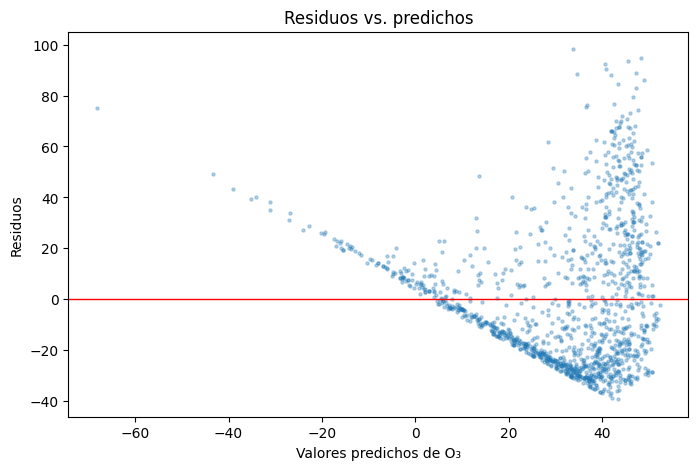

Breusch-Pagan: LM = 76.08, p-value = 1.177e-15; F = 20.14, p-value = 4.223e-16
→ Se rechaza homocedasticidad


In [ ]:
fitted = modelo.fittedvalues
resid = modelo.resid

plt.figure(figsize=(8, 5))
plt.scatter(fitted, resid, s=5, alpha=0.3)
plt.axhline(0, color="red", lw=1)
plt.xlabel("Valores predichos de O₃")
plt.ylabel("Residuos")
plt.title("Residuos vs. predichos")
plt.show()

lm, lm_p, fval, f_p = het_breuschpagan(resid, modelo.model.exog)
print(f"Breusch-Pagan: LM = {lm:.2f}, p-value = {lm_p:.4g}; F = {fval:.2f}, p-value = {f_p:.4g}")
print("-> Se rechaza homocedasticidad" if lm_p < 0.05 else "-> No se rechaza homocedasticidad")

## d) Residuos en el tiempo, promedio por hora del día y Durbin-Watson

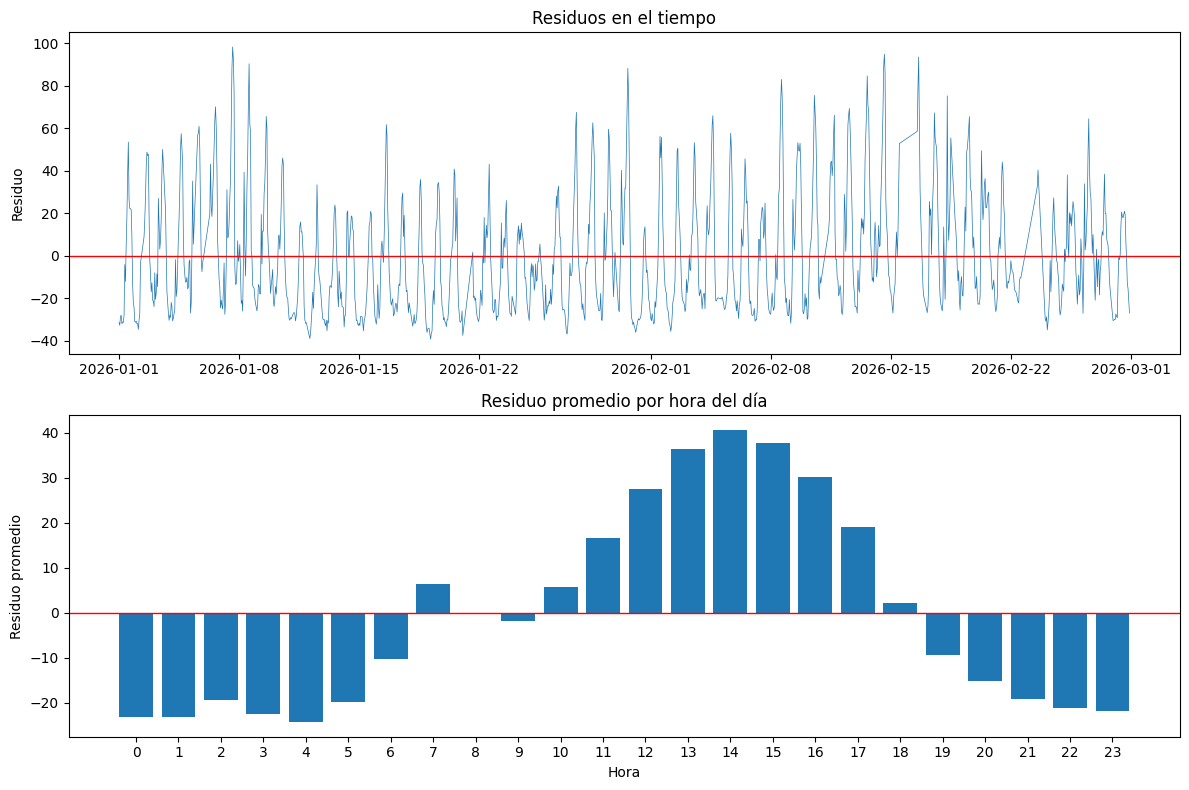

Durbin-Watson = 0.2302  (≈2 sin autocorrelación; <2 autocorrelación positiva)


In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

ax[0].plot(resid.index, resid.values, lw=0.5)
ax[0].axhline(0, color="red", lw=1)
ax[0].set_title("Residuos en el tiempo")
ax[0].set_ylabel("Residuo")

prom_hora = resid.groupby(resid.index.hour).mean()
ax[1].bar(prom_hora.index, prom_hora.values)
ax[1].axhline(0, color="red", lw=1)
ax[1].set_title("Residuo promedio por hora del día")
ax[1].set_xlabel("Hora")
ax[1].set_ylabel("Residuo promedio")
ax[1].set_xticks(range(24))
plt.tight_layout()
plt.show()

dw = durbin_watson(resid)
print(f"Durbin-Watson = {dw:.4f}  (≈2 sin autocorrelación; <2 autocorrelación positiva)")

## e) QQ-plot de los residuos

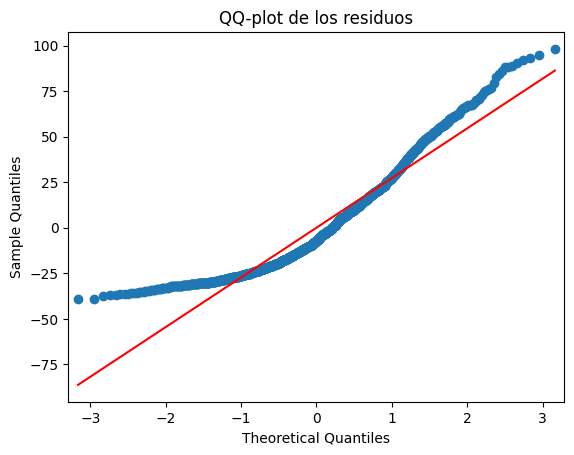

Asimetría: 0.972 | Curtosis exceso: 0.394


In [ ]:
fig = sm.qqplot(resid, line="s")
plt.title("QQ-plot de los residuos")
plt.show()

print("Asimetría:", round(stats.skew(resid), 3), "| Curtosis exceso:", round(stats.kurtosis(resid), 3))

## Resumen automático

In [ ]:
print("R²:", round(modelo.rsquared, 3))
print("Coef NO2:", round(modelo.params["NO2"], 4), "| p-value:", f"{modelo.pvalues['NO2']:.4g}")
print("VIF máx:", round(vif.loc[vif.variable != 'const', 'VIF'].max(), 1),
      "(", vif.loc[vif.variable != 'const'].sort_values('VIF').iloc[-1]['variable'], ")")
print("Breusch-Pagan p:", f"{lm_p:.4g}")
print("Durbin-Watson:", round(dw, 3))
print("Diferencia máx. de residuo promedio por hora:", round(prom_hora.max() - prom_hora.min(), 2))

R²: 0.263
Coef NO2: 0.0446 | p-value: 0.9761
VIF máx: 14676.7 ( NOX )
Breusch-Pagan p: 1.177e-15
Durbin-Watson: 0.23
Diferencia máx. de residuo promedio por hora: 64.94


## f) Conclusión

Se rompen varios supuestos del modelo lineal clásico.

**Multicolinealidad:** NOX es prácticamente NO + NO₂, así que los VIF son enormes (NO ≈ 10,180, NO₂ ≈ 1,194, NOX ≈ 14,677; solo CO ≈ 6), lo que vuelve inestables los coeficientes individuales.

**Homocedasticidad:** Breusch-Pagan rechaza varianza constante (LM = 76.1, p ≈ 1e-15) y la gráfica de residuos vs. predichos lo respalda.

**Independencia:** los residuos están fuertemente autocorrelacionados (Durbin-Watson = 0.23, muy lejos de 2) y su promedio por hora del día muestra un patrón sistemático (el ciclo fotoquímico del O₃, con una diferencia de ~65 unidades entre horas), es decir, hay estructura temporal que el modelo no captura.

**Normalidad:** el QQ-plot se desvía de la línea, sobre todo por asimetría positiva (skew ≈ 0.97, Jarque-Bera p ≈ 2e-46). Además, el R² es solo 0.26.

Por todo esto, no le creemos al coeficiente de NO₂ (0.045, p = 0.976) ni a su p-value: el coeficiente no es distinguible de cero, pero eso no significa que NO₂ no afecte al O₃, sino que con NO y NOX casi idénticos el modelo no puede separar sus efectos (errores estándar inflados), y con autocorrelación y heterocedasticidad los p-values además están mal calculados. Sería más razonable dejar solo una de NO/NO₂/NOX, incluir hora del día (y variables meteorológicas), y usar errores robustos HAC (Newey-West) o un modelo de series de tiempo.